# 改进Seq2Seq模型：反转输入


通过本次任务，你将学会如何使用信息反转改进 Seq2Seq 生成式模型的效果。

## 介绍

上一章我们构建了一个Seq2Seq模型，使用生成式模型解决加法计算问题。虽然模型具备一定的泛化能力，但在评估集上的准确率只有 `16.09%`，本章我们将通过改进数据处理的方式来提高模型生成的效果。

![改进点示意图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260302094018.png)

## 任务鸟瞰

### 任务介绍

本次我们使用一个简单到匪夷所思的技巧 `反转输入` 来提高Seq2Seq模型生成的效果。反转输入是指将输入数据进行反转，比如输入 `12+8`，反转后为 `8+21`。

![反转输入示意图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260302094032.png)


### 模型结构

这次的改动主要在数据处理上，只是将输入数据进行反转，未改变模型的结构。

![输入反转后的流程示意图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260302094025.png)


输入反转前编码器处理过程：

![编码器的计算示例](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260220061924.png)


反转输入后编码器处理过程：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260302094050.png)

由上面的两张图，我们可以看到输入数据反转后，有效数据位置更接近最终的输出，而填充的 `Pad` 位置在最前面，减少了编码时噪声的引入。直观上来说，输入反转后，这应该可以提高模型生成的效果，但具体效果还需通过实践来验证。

## 环境配置

### 安装依赖

In [1]:
!pip install --upgrade dsxllm

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple


### 环境版本

照例我们先打印环境版本信息，方便大家进行代码复现。

In [2]:
from dsxllm.util import show_version

show_version()

本书愿景：
+------+--------------------------------------------------------+
| Info |                  《动手学大语言模型》                  |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.10.0    |         2.6.1          |
+-------------+--------------+------------------------+


## 数据准备

### 数据集下载

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>

### 自定义分词器

在分词时，需要进行长度对齐，处理过程如下：

![分词结果](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260222044655.png)

以 `12+8` 为例，最终会被处理成如下 json 格式：

```json
[
    {
        "input_ids": [1, 2, 10, 8, 12, 12, 12],
        "attention_mask": [1, 1, 1, 1, 0, 0, 0]
    }
]
```

其中 `input_ids` 表示输入序列的 token ID 序列，`attention_mask` 表示输入序列的 pad-mask 序列。

#### 加法分词器的代码实现

这部分代码和之前的一致，不再详细介绍，请自行查看代码。

In [3]:
from dsxllm.util import print_table
import torch


class SimpleTokenizer:
    def __init__(self, vocab, pad_token="<|pad|>", unk_token="<|unk|>", bos_token="<|bos|>", eos_token="<|eos|>"):
        """
        初始化简单分词器
        """

        self.vocab = vocab

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 特殊token
        self.pad_token = pad_token
        self.pad_token_id = self.vocab[pad_token]

        self.unk_token = unk_token
        self.unk_token_id = self.vocab[unk_token]

        self.bos_token = bos_token
        self.bos_token_id = self.vocab[bos_token]

        self.eos_token = eos_token
        self.eos_token_id = self.vocab[eos_token]

        self.special_tokens = [self.pad_token, self.unk_token, self.bos_token, self.eos_token]

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def encode(self, text):
        # 将文本拆分为单个字符和特殊标记
        tokens = self._tokenize_special_tokens(text)

        # 将每个token转换为对应的token ID
        input_ids = [self.vocab[token] for token in tokens if token in self.vocab]

        return input_ids

    def _tokenize_special_tokens(self, text):
        # 识别并处理特殊标记
        tokens = []
        i = 0
        while i < len(text):
            # 检查是否匹配特殊标记
            for token in self.special_tokens:
                if text[i:i + len(token)] == token:
                    tokens.append(token)
                    i += len(token)
                    break
            else:
                # 如果不是特殊标记，则逐个字符处理
                tokens.append(text[i])
                i += 1
        return tokens

    def decode(self, input_ids, skip_special_tokens=True):
        # 如果 input_ids 是 torch.Tensor，则转换为列表
        if isinstance(input_ids, torch.Tensor):
            input_ids = input_ids.squeeze().tolist()

        # 将token ID序列转换为对应的字符
        tokens = [self.ids_to_tokens.get(id) for id in input_ids]

        # 去除开始符和结束符
        if skip_special_tokens:
            tokens = [token for token in tokens if token not in self.special_tokens]
        return ''.join(tokens)

    def __call__(self, texts, max_length=None, padding=False, return_tensors=False):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        all_attention_masks = []

        for text in texts:
            token_ids = self.encode(text)

            # 处理填充和注意力掩码
            if padding and max_length is not None:
                attention_mask = [1] * len(token_ids) + [0] * (max_length - len(token_ids))
                token_ids += [self.pad_token_id] * (max_length - len(token_ids))
            else:
                attention_mask = [1] * len(token_ids)

            all_token_ids.append(token_ids)
            all_attention_masks.append(attention_mask)

        if is_single_text:
            all_token_ids = all_token_ids[0]
            all_attention_masks = all_attention_masks[0]

        # 转换为tensor
        if return_tensors:
            all_token_ids = torch.tensor(all_token_ids, dtype=torch.long)
            all_attention_masks = torch.tensor(all_attention_masks, dtype=torch.long)

        return {'input_ids': all_token_ids, 'attention_mask': all_attention_masks}

    def info(self):
        """
        打印分词器的详细信息
        """

        # 通用信息表
        info_data = [
            ["Vocabulary Size", self.vocab_size],
            ["Padding Token", f"{self.pad_token} (ID: {self.pad_token_id})"],
            ["Unknown Token", f"{self.unk_token} (ID: {self.unk_token_id})"],
            ["Start Token", f"{self.bos_token} (ID: {self.bos_token_id})"],
            ["End Token", f"{self.eos_token} (ID: {self.eos_token_id})"]
        ]

        print_table("General Information", field_names=["Information", "Value"], data=info_data)

        # 字符到ID的映射表
        print_table("Token Mapping", field_names=["Token", "ID"], data=[
            [char, char_id] for char, char_id in self.vocab.items()
        ])

        # 编码解码示例表
        example = "12+8"  # 示例输入

        encode_result = self(example, max_length=7, padding=True)

        print_table("Encoding and Decoding Example", field_names=["Field", "Value"], data=[
            ["Input", example],
            ["Token Ids", encode_result['input_ids']],
            ["Pad Mask", encode_result['attention_mask']],
            ["Decode", self.decode(encode_result['input_ids'])]
        ])

#### 创建加法分词器的实例

In [4]:
# 定义词汇表，将每个字符映射到唯一的索引编号
vocab = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "+": 10,
    "=": 11,
    "<|pad|>": 12,
    "<|unk|>": 13,
    "<|bos|>": 14,
    "<|eos|>": 15
}

# 使用定义的词汇表创建分词器实例
tokenizer = SimpleTokenizer(vocab)

# 打印分词器信息
tokenizer.info()

General Information：
+-----------------+------------------+
|   Information   |      Value       |
+-----------------+------------------+
| Vocabulary Size |        16        |
|  Padding Token  | <|pad|> (ID: 12) |
|  Unknown Token  | <|unk|> (ID: 13) |
|   Start Token   | <|bos|> (ID: 14) |
|    End Token    | <|eos|> (ID: 15) |
+-----------------+------------------+
Token Mapping：
+---------+----+
|  Token  | ID |
+---------+----+
|    0    | 0  |
|    1    | 1  |
|    2    | 2  |
|    3    | 3  |
|    4    | 4  |
|    5    | 5  |
|    6    | 6  |
|    7    | 7  |
|    8    | 8  |
|    9    | 9  |
|    +    | 10 |
|    =    | 11 |
| <|pad|> | 12 |
| <|unk|> | 13 |
| <|bos|> | 14 |
| <|eos|> | 15 |
+---------+----+
Encoding and Decoding Example：
+-----------+---------------------------+
|   Field   |           Value           |
+-----------+---------------------------+
|   Input   |            12+8           |
| Token Ids | [1, 2, 10, 8, 12, 12, 12] |
|  Pad Mask |   [1, 1, 1, 1, 0, 

### 实现带反转的数据转换器

在数据转换器中，使用分词器将文本转换为指定长度的 token ID 序列以及对应的填充掩码，并控制是否进行反转。反转输入的效果如下图所示：

![数据反转示意图](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260302094440.png)

这里需要注意，反转输入时，除了对输入进行反转，还要对填充掩码进行反转。

In [5]:
class TextTransform:
    def __init__(self, tokenizer: SimpleTokenizer, max_length=20, is_reverse=False):
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.is_reverse = is_reverse

    def __call__(self, text):
        if self.is_reverse:
            # 进行反转
            encoded = self.tokenizer(text, max_length=self.max_length, padding=True, return_tensors=True)

            encoder_input_ids = encoded['input_ids']
            encoder_pad_mask = encoded['attention_mask']

            # 输入反转，注意：torch.flip 会创建新的张量，不会修改原张量
            encoder_input_ids = torch.flip(encoder_input_ids, dims=[-1])
            encoder_pad_mask = torch.flip(encoder_pad_mask, dims=[-1])

            return {
                "input_ids": encoder_input_ids,
                "attention_mask": encoder_pad_mask,
            }
        else:
            # 不进行反转
            return self.tokenizer(text, max_length=self.max_length, padding=True, return_tensors=True)

In [6]:
txt = "12+8"
print("原始输入：", txt)

text_transform = TextTransform(tokenizer, max_length=7, is_reverse=False)

print("原始结果：", text_transform(txt))

text_transform_reversed = TextTransform(tokenizer, max_length=7, is_reverse=True)
print("反转结果：", text_transform_reversed(txt))

原始输入： 12+8
原始结果： {'input_ids': tensor([ 1,  2, 10,  8, 12, 12, 12]), 'attention_mask': tensor([1, 1, 1, 1, 0, 0, 0])}
反转结果： {'input_ids': tensor([12, 12, 12,  8, 10,  2,  1]), 'attention_mask': tensor([0, 0, 0, 1, 1, 1, 1])}


### 构造加法数据集

以 `16+75=91` 为，将每个加法算式和对应的答案都转化成如下 json 格式：
```json
{
    'question': '16+75',
    'answer': '91',
    'encoder_input_ids': tensor([1,  6, 10,  7,  5, 12, 12]),
    'encoder_pad_mask': tensor([1, 1, 1, 1, 1, 0, 0]),
    'decoder_target_ids': tensor([ 9,  1, 12, 12]),
    'decoder_pad_mask': tensor([1, 1, 0, 0])
}
```

转化后的数据集将包含以下字段：
- `question`: 加法算式的原始文本
- `answer`: 对应的答案（**便于评估测试**）
- `encoder_input_ids`: 加法算式经过分词器转换得到的 Token ID 序列（**编码器的输入**）
- `encoder_pad_mask`: 对应的填充掩码（**编码器输入的填充掩码**）
- `decoder_target_ids`: 答案经过分词器转换得到的 Token ID 序列（**解码器的目标输出**）
- `decoder_pad_mask`: 答案对应的填充掩码（**解码器输出的填充掩码**）

#### 加法数据集的代码实现

In [7]:
from torch.utils.data import Dataset


class TextGenerationDataset(Dataset):
    """
    文本生成任务的数据集类
    用于处理序列到序列的文本生成任务，如加法计算等
    """

    def __init__(
        self,
        questions,
        answers,
        encoder_transform: TextTransform,
        decoder_transform: TextTransform,
    ):
        """
        初始化数据集

        Args:
            questions: 输入问题列表
            answers: 对应答案列表
            encoder_transform: 编码器文本转换器
            decoder_transform: 解码器文本转换器
        """
        self.questions = questions  # 存储输入问题列表
        self.answers = answers  # 存储对应答案列表
        self.encoder_transform = encoder_transform  # 编码器文本预处理工具
        self.decoder_transform = decoder_transform  # 解码器文本预处理工具

    def __len__(self):
        """返回数据集大小"""
        return len(self.questions)

    def __getitem__(self, idx):
        """
        获取指定索引的数据样本

        Args:
            idx: 样本索引

        Returns:
            dict: 包含处理后的输入输出数据的字典
        """
        question = self.questions[idx]  # 获取第idx个问题
        answer = self.answers[idx]  # 获取第idx个答案

        # 对输入问题进行预处理
        question_encoded = self.encoder_transform(question)
        encoder_input_ids = question_encoded["input_ids"]  # 编码器输入token ID序列
        encoder_pad_mask = question_encoded["attention_mask"]  # 编码器注意力掩码

        # 对目标答案进行预处理
        answer_encoded = self.decoder_transform(answer)
        answer_ids = answer_encoded["input_ids"]  # 解码器目标token ID序列
        answer_pad_mask = answer_encoded["attention_mask"]  # 解码器注意力掩码

        # 返回完整的数据样本
        return {
            "question": question,  # 原始问题文本
            "answer": answer,  # 原始答案文本
            "encoder_input_ids": encoder_input_ids,  # 编码器输入IDs
            "encoder_pad_mask": encoder_pad_mask,  # 编码器填充掩码
            "decoder_target_ids": answer_ids,  # 解码器目标IDs
            "decoder_pad_mask": answer_pad_mask,  # 解码器填充掩码
        }

    @classmethod
    def from_file(
        cls,
        file_path,
        encoder_transform: TextTransform,
        decoder_transform: TextTransform,
    ):
        """
        从txt文件加载数据集的类方法

        Args:
            file_path: 数据文件路径
            encoder_transform: 编码器文本转换器
            decoder_transform: 解码器文本转换器

        Returns:
            TextGenerationDataset: 数据集实例

        Note:
            txt格式应包含算式，使用等号分隔问题和答案
            例如: "123+456=579"
        """

        questions = []  # 存储解析出的问题
        answers = []  # 存储解析出的答案

        # 读取txt文件
        with open(file_path, "r", encoding="utf-8") as f:
            for line in f:
                if line.strip() == "":  # 跳过空行
                    continue
                try:
                    # 查找等号的位置，将行分割为问题和答案
                    idx = line.find("=")
                    # 将样本添加到列表中: (question, answer)，answer中去掉"="以及最后的"\n"
                    question = line[:idx]  # 等号前的部分作为问题
                    answer = line[
                        idx + 1 :
                    ].strip()  # 等号后的部分作为答案（去除首尾空白）
                    questions.append(question)
                    answers.append(answer)
                except Exception as e:
                    # 如果处理某行时出错，打印错误信息并跳过
                    print(f"Error processing line: {line}")
                    print(f"Error message: {e}")
                    continue

        # 创建数据集实例
        return cls(questions, answers, encoder_transform, decoder_transform)

#### 创建加法数据集的实例

In [8]:
from pprint import pprint

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab)

# 2️⃣ 初始化数据转换
encoder_transform = TextTransform(tokenizer, max_length=7, is_reverse=True) # 编码器的输入算式进行反转
decoder_transform = TextTransform(tokenizer, max_length=4) # 解码器的输出结果不进行反转

# 3️⃣ 加载数据集
file_path = "./dataset/addition_train.txt"
dataset = TextGenerationDataset.from_file(file_path, encoder_transform=encoder_transform,
                                          decoder_transform=decoder_transform)

# 4️⃣ 打印数据样本，确认数据正确转换
pprint(dataset[0], sort_dicts=False)

{'question': '12+991',
 'answer': '1003',
 'encoder_input_ids': tensor([12,  1,  9,  9, 10,  2,  1]),
 'encoder_pad_mask': tensor([0, 1, 1, 1, 1, 1, 1]),
 'decoder_target_ids': tensor([1, 0, 0, 3]),
 'decoder_pad_mask': tensor([1, 1, 1, 1])}


### 初始化数据模组

加法数据模组继承自 LightningDataModule，用于统一管理训练、验证和测试数据集。

In [9]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    """
    文本生成任务的数据模块
    继承自LightningDataModule，用于管理训练、验证和测试数据的加载
    """

    def __init__(
        self,
        batch_size,
        encoder_transform: TextTransform,
        decoder_transform: TextTransform,
        train_data_file,
        val_data_file="",
        test_data_file="",
    ):
        """
        初始化数据模块

        Args:
            batch_size: 批次大小
            encoder_transform: 编码器文本转换器
            decoder_transform: 解码器文本转换器
            train_data_file: 训练数据文件路径
            val_data_file: 验证数据文件路径（可选）
            test_data_file: 测试数据文件路径（可选）
        """
        super().__init__()

        self.batch_size = batch_size  # 设置批次大小
        self.encoder_transform = encoder_transform  # 编码器文本预处理转换器
        self.decoder_transform = decoder_transform  # 解码器文本预处理转换器

        self.train_data_file = train_data_file  # 训练数据文件路径
        self.val_data_file = val_data_file  # 验证数据文件路径
        self.test_data_file = test_data_file  # 测试数据文件路径

        # 初始化数据集属性
        self.test_dataset = None  # 测试数据集
        self.val_dataset = None  # 验证数据集
        self.train_dataset = None  # 训练数据集

    def prepare_data(self):
        """
        准备数据的方法
        用于下载数据集或进行一次性数据预处理操作
        """
        pass

    def setup(self, stage=None):
        """
        设置数据集的方法
        """
        # 加载训练数据集
        self.train_dataset = TextGenerationDataset.from_file(
            self.train_data_file,
            encoder_transform=self.encoder_transform,
            decoder_transform=self.decoder_transform,
        )

        # 加载验证数据集
        if self.val_data_file == "":
            # 如果没有指定验证集，则使用训练集作为验证集
            self.val_dataset = self.train_dataset
        else:
            # 加载指定的验证数据集
            self.val_dataset = TextGenerationDataset.from_file(
                self.val_data_file,
                encoder_transform=self.encoder_transform,
                decoder_transform=self.decoder_transform,
            )

        # 加载测试数据集
        if self.test_data_file == "":
            # 如果没有指定测试集，则使用训练集作为测试集
            self.test_dataset = self.train_dataset
        else:
            # 加载指定的测试数据集
            self.test_dataset = TextGenerationDataset.from_file(
                self.test_data_file,
                encoder_transform=self.encoder_transform,
                decoder_transform=self.decoder_transform,
            )

    def train_dataloader(self):
        """
        返回训练数据加载器

        Returns:
            DataLoader: 训练数据的DataLoader对象
        """
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        """
        返回验证数据加载器

        Returns:
            DataLoader: 验证数据的DataLoader对象
        """
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        """
        返回测试数据加载器

        Returns:
            DataLoader: 测试数据的DataLoader对象
        """
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

## 构建模型

在此次的改进中，未对模型进行任何改进。先定义 Encoder 和 Decoder 模型，然后定义一个完整的 Seq2Seq 模型。


### 编码器的代码实现

In [10]:
import torch


class Encoder(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(Encoder, self).__init__()

        # 词嵌入层
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)

        # GRU
        self.gru = torch.nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

    def forward(self, input_ids):
        """
        前向传播
        
        参数:
            input_ids (Tensor): 输入序列的token IDs, shape: [batch_size, seq_len]
            
        返回:
            outputs (Tensor): 编码器所有时间步的输出, shape: [batch_size, seq_len, hidden_dim]
            hidden (Tensor): 编码器最后时间步的隐藏状态, shape: [num_layers, batch_size, hidden_dim]
        """
        embedded = self.embedding(input_ids)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

### 解码器的代码实现

In [11]:
class Decoder(torch.nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super(Decoder, self).__init__()

        # 词嵌入层
        self.embedding = torch.nn.Embedding(vocab_size, embed_dim)

        # GRU
        self.gru = torch.nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        # 输出层
        self.output_layer = torch.nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_ids, hidden):
        """
        前向传播
        
        参数:
            input_ids (Tensor): 目标序列的token IDs, shape: [batch_size, seq_len]
            hidden (Tensor): 编码器的最终隐藏状态, shape: [num_layers, batch_size, hidden_dim]
            
        返回:
            output_logits (Tensor): 每个时间步的词汇表分布, shape: [batch_size, seq_len, vocab_size]
            hidden (Tensor): 解码器最后时间步的隐藏状态, shape: [num_layers, batch_size, hidden_dim]
        """
        embedded = self.embedding(input_ids)
        outputs, hidden = self.gru(embedded, hidden)
        output_logits = self.output_layer(outputs)
        return output_logits, hidden

    def forward_step(self, input_id, hidden):
        """
        单步解码：
        - 输入：当前时间步的输入和隐藏状态
        - 输出：当前时间步的输出和新的隐藏状态
        """
        token_embed = self.embedding(input_id)
        output, hidden = self.gru(token_embed, hidden)
        output_logits = self.output_layer(output)
        return output_logits, hidden

### 完整的 Seq2Seq 模型

In [12]:
class SequenceGenerator(L.LightningModule):
    def __init__(
        self,
        tokenizer: SimpleTokenizer,
        embed_dim,
        hidden_dim,
        num_layers=1,
        learning_rate=1e-3,
        generate_max_length=4,
    ):
        super().__init__()

        # 实例化编码器和解码器
        self.encoder = Encoder(tokenizer.vocab_size, embed_dim, hidden_dim, num_layers)
        self.decoder = Decoder(tokenizer.vocab_size, embed_dim, hidden_dim, num_layers)

        self.tokenizer = tokenizer
        self.learning_rate = learning_rate
        self.generate_max_length = generate_max_length  # 添加最大长度属性

        # 用于存储训练和验证过程中的指标
        self.train_step_losses = []
        self.train_epoch_losses = []
        self.validation_step_outputs = []
        self.validation_epoch_outputs = []

        # 示例输入
        self.example_input_array = (
            torch.randint(0, tokenizer.vocab_size, (32, 10), dtype=torch.long),
            torch.randint(0, tokenizer.vocab_size, (32, 5), dtype=torch.long),
        )

    def forward(self, input_ids, target_ids=None):
        """前向传播"""
        batch_size = input_ids.size(0)

        # 1. 编码阶段：提取输入序列特征
        encoder_outputs, encoder_hidden = self.encoder(input_ids)

        # 2. 解码阶段：生成输出序列
        if target_ids is not None:
            # 训练过程：使用真实目标序列作为输入（teacher forcing）
            return self._decode_with_targets(
                encoder_outputs, encoder_hidden, target_ids, self.generate_max_length
            )
        else:
            # 推理过程：自回归生成序列
            return self._decode_autoregressive(
                encoder_outputs, encoder_hidden, batch_size, self.generate_max_length
            )

    def _decode_with_targets(
        self, encoder_outputs, encoder_hidden, target_ids, generate_max_length
    ):
        """
        训练阶段解码：使用teacher forcing
        """
        batch_size = encoder_outputs.size(0)

        # 初始化解码器输入为起始标记（这里假设用空格作为起始符，ID为12）
        decoder_input = torch.full(
            (batch_size, 1),
            self.tokenizer.bos_token_id,
            device=encoder_outputs.device,
            dtype=torch.long,
        )
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        # 使用目标序列作为输入，逐步解码
        for i in range(generate_max_length):
            decoder_output, decoder_hidden = self.decoder.forward_step(
                decoder_input, decoder_hidden
            )
            decoder_outputs.append(decoder_output)

            # 使用真实目标作为下一步输入
            decoder_input = target_ids[:, i].unsqueeze(1)

        # 拼接所有时间步的输出
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return torch.nn.functional.log_softmax(decoder_outputs, dim=-1)

    def _decode_autoregressive(
        self, encoder_outputs, encoder_hidden, batch_size, generate_max_length
    ):
        """
        推理阶段解码：自回归生成
        """
        # 初始化解码器输入为起始标记
        decoder_input = torch.full(
            (batch_size, 1),
            self.tokenizer.bos_token_id,
            device=encoder_outputs.device,
            dtype=torch.long,
        )
        decoder_hidden = encoder_hidden
        decoder_outputs = []

        for i in range(generate_max_length):
            # 单步解码
            decoder_output, decoder_hidden = self.decoder.forward_step(
                decoder_input, decoder_hidden
            )
            decoder_outputs.append(decoder_output)

            # 使用模型预测作为下一步输入
            _, topi = decoder_output.topk(1)
            decoder_input = topi.squeeze(-1).detach()

        # 拼接所有时间步的输出
        decoder_outputs = torch.cat(decoder_outputs, dim=1)
        return torch.nn.functional.log_softmax(decoder_outputs, dim=-1)

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["encoder_input_ids"]
        target_ids = batch["decoder_target_ids"]

        # 前向传播
        outputs = self(input_ids, target_ids)  # 训练时传入target_ids

        # 计算损失 - 需要调整维度以适应交叉熵损失
        # outputs: [batch_size, seq_len, vocab_size]
        # target_ids: [batch_size, seq_len]
        loss = torch.nn.functional.cross_entropy(
            outputs.view(-1, outputs.size(-1)), target_ids.view(-1)
        )

        """
        对于序列生成任务，通常我们会采用以下几种方式来计算准确率：
            1. 序列级别准确率：整个生成序列完全匹配目标序列才算正确
            2. token级别准确率：计算所有token中预测正确的比例
            3. BLEU/ROUGE等评价指标：更复杂的文本生成评价指标
        """
        # 计算token级别的准确率
        preds = torch.argmax(outputs, dim=-1)
        mask = target_ids != self.tokenizer.pad_token_id  # 忽略填充位置
        correct_tokens = ((preds == target_ids) & mask).sum().float()
        total_tokens = mask.sum().float()
        token_acc = correct_tokens / total_tokens

        # 计算序列级别的准确率
        # 对于每个序列，只有当所有非填充位置都预测正确才算正确
        seq_correct = ((preds == target_ids) | ~mask).all(dim=1).float().mean()

        # 记录日志
        self.log("train_loss", loss)
        self.log("train_token_acc", token_acc)
        self.log("train_seq_acc", seq_correct)

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())

        return loss

    def validation_step(self, batch, batch_idx):
        """验证步骤"""

        input_ids = batch["encoder_input_ids"]
        target_ids = batch["decoder_target_ids"]

        # 前向传播
        outputs = self(input_ids)

        # 计算预测值
        preds = torch.argmax(outputs, dim=-1)

        # 创建掩码以忽略填充值
        mask = target_ids != self.tokenizer.pad_token_id

        # 计算token级别的准确率
        correct_tokens = ((preds == target_ids) & mask).sum().float()
        total_tokens = mask.sum().float()
        token_acc = (
            correct_tokens / total_tokens if total_tokens > 0 else torch.tensor(0.0)
        )

        # 计算序列级别的准确率
        seq_correct = ((preds == target_ids) | ~mask).all(dim=1).float().mean()

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append(
            {
                "preds": preds,
                "target_ids": target_ids,
                "token_acc": token_acc,
                "seq_acc": seq_correct,
            }
        )

        if batch_idx % 50 == 0:
            print(
                f"Validation Step {batch_idx}: Token Accuracy={token_acc.item():.4f}, Seq Accuracy={seq_correct.item():.4f}"
            )

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()
            self.train_epoch_losses.append(
                {
                    "epoch": self.current_epoch,
                    "loss": avg_train_loss.item(),  # 转换为 Python 数值
                }
            )

            # 清空列表为下一个 epoch 做准备
            self.train_step_losses.clear()

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x["preds"] for x in self.validation_step_outputs])
        all_target_ids = torch.cat(
            [x["target_ids"] for x in self.validation_step_outputs]
        )

        # 1. 计算序列（样本）级别的准确率
        # 创建掩码以标识非填充位置
        mask = all_target_ids != self.tokenizer.pad_token_id
        # 计算每个序列是否完全正确（所有非填充位置都预测正确）
        seq_correct = ((all_preds == all_target_ids) | ~mask).all(dim=1)
        # 序列总数
        total_sequences = all_preds.size(0)
        # 正确预测的序列数
        correct_sequences = seq_correct.sum().item()
        # 序列级别准确率
        seq_acc = correct_sequences / total_sequences if total_sequences > 0 else 0.0

        # 2. 计算 Token 级别的准确率
        # 计算所有非填充位置的预测总数
        total_tokens = mask.sum().item()
        # 计算所有非填充位置预测正确的总数
        correct_tokens = ((all_preds == all_target_ids) & mask).sum().item()
        # Token 级别准确率
        token_acc = correct_tokens / total_tokens if total_tokens > 0 else 0.0

        # 3. 将评估结果保存到 validation_epoch_outputs 列表中
        self.validation_epoch_outputs.append(
            {
                "epoch": self.current_epoch,
                "总样本数": total_sequences,
                "正确样本数": correct_sequences,
                "样本准确率": round(seq_acc, 4),
                "总Token数": total_tokens,
                "正确Token数": correct_tokens,
                "Token准确率": round(token_acc, 4),
            }
        )

        # 记录日志
        self.log("total_sequences", total_sequences)
        self.log("correct_sequences", correct_sequences)
        self.log("seq_acc", seq_acc)

        self.log("total_tokens", total_tokens)
        self.log("correct_tokens", correct_tokens)
        self.log("token_acc", token_acc)

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()
        self.train_epoch_losses.clear()
        self.validation_step_outputs.clear()
        self.validation_epoch_outputs.clear()

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)
        return optimizer

    def generate(self, input_ids):
        """
        根据输入序列生成输出序列文本

        参数:
            input_ids (Tensor): 输入序列的token IDs, shape: [batch_size, seq_len]

        返回:
            generated_texts (list): 生成的文本列表
        """
        # 1. 调用模型的 forward 方法 (推理模式，无 target_ids) 生成 logits
        generated_logits = self(
            input_ids
        )  # Shape: [batch_size, generate_max_length, vocab_size]

        # 2. 获取概率最高的 token ID
        generated_ids = torch.argmax(
            generated_logits, dim=-1
        )  # Shape: [batch_size, generate_max_length]

        # 3. 直接使用 tokenizer.decode 方法将 token ID 转换为文本
        generated_texts = []
        for i in range(generated_ids.size(0)):  # 遍历 batch 中的每个样本
            # 调用 tokenizer 的 decode 方法，并跳过特殊 token
            text = self.tokenizer.decode(generated_ids[i], skip_special_tokens=True)
            generated_texts.append(text)

        return generated_texts

#### 查看模型的详细信息

In [13]:
from lightning.pytorch.utilities.model_summary import ModelSummary

# 创建加法计算模型实例：词嵌入维度128，隐藏层维度128
model = SequenceGenerator(tokenizer, embed_dim=128, hidden_dim=128)

# 使用 ModelSummary 获取模型详细信息
summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name                 | Type      | Params | Mode  | FLOPs  | In sizes                     | Out sizes                    
-----------------------------------------------------------------------------------------------------------------------------------
0 | encoder              | Encoder   | 101 K  | train | 62.9 M | [32, 10]                     | [[32, 10, 128], [1, 32, 128]]
1 | encoder.embedding    | Embedding | 2.0 K  | train | 0      | [32, 10]                     | [32, 10, 128]                
2 | encoder.gru          | GRU       | 99.1 K | train | 62.9 M | [32, 10, 128]                | [[32, 10, 128], [1, 32, 128]]
3 | decoder              | Decoder   | 103 K  | train | 0      | ?                            | ?                            
4 | decoder.embedding    | Embedding | 2.0 K  | train | 0      | [32, 1]                      | [32, 1, 128]                 
5 | decoder.gru          | GRU       | 99.1 K | train | 25.2 M | [[32, 1, 128], [1, 32, 128]] | [[32, 1, 128], [

从模型的详细信息中可以看到，本次的模型结构与前一章的模型一模一样，未做任何改变。我们这次只单纯改变输入数据的处理方式，观察对模型训练效果的影响。

## 模型训练与评估

### 初始化模型和训练器

In [14]:
# 超参配置
batch_size = 50
encoder_max_length = 7
decoder_max_length = 4

# 1️⃣ 初始化分词器
tokenizer = SimpleTokenizer(vocab)

# 2️⃣ 初始化编码器和解码器的数据转换
encoder_transform = TextTransform(tokenizer, max_length=encoder_max_length, is_reverse=True)
decoder_transform = TextTransform(tokenizer, max_length=decoder_max_length)

# 3️⃣ 加载数据模组
train_data_file = "./dataset/addition_train.txt"
val_data_file = "./dataset/addition_val.txt"

# 此处的直接使用评估集进行评估
datamodule = TextDataModule(batch_size=batch_size, encoder_transform=encoder_transform,
                            decoder_transform=decoder_transform, train_data_file=train_data_file, val_data_file=val_data_file)

# 4️⃣ 初始化模型
model = SequenceGenerator(tokenizer, embed_dim=128, hidden_dim=128)

# 5️⃣ 初始化训练器
# max_epochs=12: 最大训练轮数为12
# log_every_n_steps=3: 每3个步骤记录一次日志
# check_val_every_n_epoch=1: 每1个epoch进行一次验证
# num_sanity_val_steps=0: 验证集的初始检查次数，设置为0表示不进行初始检查
# enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


### 训练前评估

训练前评估为模型性能建立初始性能基准。

In [15]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Validation Step 0: Token Accuracy=0.0255, Seq Accuracy=0.0000
Validation Step 50: Token Accuracy=0.0377, Seq Accuracy=0.0000


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     correct_sequences     │            3.0            │
│      correct_tokens       │           355.0           │
│          seq_acc          │   0.0006000000284984708   │
│         token_acc         │    0.02259131893515587    │
│      total_sequences      │          5000.0           │
│       total_tokens        │          15714.0          │
└───────────────────────────┴───────────────────────────┘

[{'total_sequences': 5000.0,
  'correct_sequences': 3.0,
  'seq_acc': 0.0006000000284984708,
  'total_tokens': 15714.0,
  'correct_tokens': 355.0,
  'token_acc': 0.02259131893515587}]

在评估集的 5000 条数据上，只有 3 个样本的预测结果正确，模型训练前预测正确率为 `0.06%`，不具备预测效果。

### 训练模型

调用 `trainer.fit()` 训练 12 个轮次。

In [16]:
model.clear_cache()
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃  FLOPs ┃ In sizes ┃                     Out sizes ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 0 │ encoder │ Encoder │  101 K │ train │ 62.9 M │ [32, 10] │ [[32, 10, 128], [1, 32, 128]] │
│ 1 │ decoder │ Decoder │  103 K │ train │      0 │        ? │                             ? │
└───┴─────────┴─────────┴────────┴───────┴────────┴──────────┴───────────────────────────────┘

Trainable params: 204 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 204 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 88.6 M

Validation Step 0: Token Accuracy=0.5350, Seq Accuracy=0.0800
Validation Step 50: Token Accuracy=0.5220, Seq Accuracy=0.0800
Validation Step 0: Token Accuracy=0.6178, Seq Accuracy=0.1800
Validation Step 50: Token Accuracy=0.6164, Seq Accuracy=0.1800
Validation Step 0: Token Accuracy=0.5924, Seq Accuracy=0.1400
Validation Step 50: Token Accuracy=0.6038, Seq Accuracy=0.1400
Validation Step 0: Token Accuracy=0.6561, Seq Accuracy=0.1800
Validation Step 50: Token Accuracy=0.5849, Seq Accuracy=0.0800
Validation Step 0: Token Accuracy=0.7006, Seq Accuracy=0.2800
Validation Step 50: Token Accuracy=0.5849, Seq Accuracy=0.2000
Validation Step 0: Token Accuracy=0.6497, Seq Accuracy=0.1800
Validation Step 50: Token Accuracy=0.6038, Seq Accuracy=0.1800
Validation Step 0: Token Accuracy=0.7070, Seq Accuracy=0.2800
Validation Step 50: Token Accuracy=0.5975, Seq Accuracy=0.1800
Validation Step 0: Token Accuracy=0.6879, Seq Accuracy=0.2400
Validation Step 50: Token Accuracy=0.6164, Seq Accuracy=0.2000


`Trainer.fit` stopped: `max_epochs=12` reached.


#### 训练过程可视化
绘制训练过程中损失值的变化曲线。

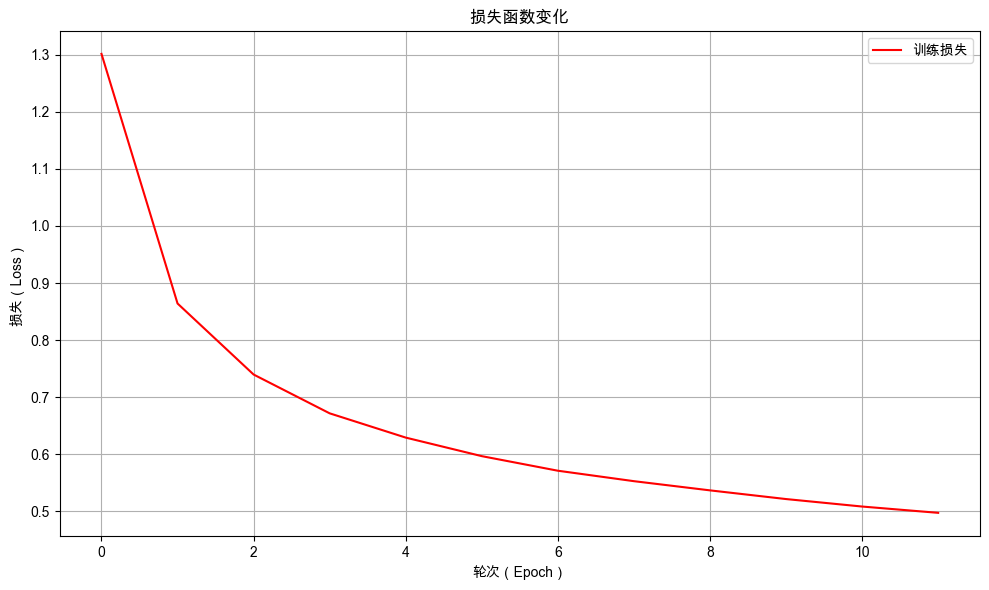

In [17]:
from dsxllm.util import plot_loss_curves

plot_loss_curves(model.train_epoch_losses)


#### 查看模型评估记录

查看训练过程中的评估结果，观察模型在验证集上的表现。

In [18]:
from dsxllm.util import to_dataframe

to_dataframe(model.validation_epoch_outputs)


,epoch,总样本数,正确样本数,样本准确率,总Token数,正确Token数,Token准确率
0,0,5000,318,0.0636,15714,8142,0.5181
1,1,5000,603,0.1206,15714,9184,0.5844
2,2,5000,730,0.1460,15714,9648,0.6140
3,3,5000,846,0.1692,15714,9901,0.6301
4,4,5000,967,0.1934,15714,10219,0.6503
5,5,5000,1106,0.2212,15714,10354,0.6589
6,6,5000,1151,0.2302,15714,10459,0.6656
7,7,5000,1191,0.2382,15714,10612,0.6753
8,8,5000,1325,0.2650,15714,10848,0.6903
9,9,5000,1361,0.2722,15714,10931,0.6956


### 训练后评估

与训练前的评估结果对比，确认模型训练效果是否有效。

In [19]:
# 直接调用验证函数进行训练前评估
trainer.validate(model=model, datamodule=datamodule)

/Users/kong/opt/anaconda3/envs/dsx-ai/lib/python3.12/site-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Validation Step 0: Token Accuracy=0.6815, Seq Accuracy=0.2200
Validation Step 50: Token Accuracy=0.6352, Seq Accuracy=0.1800


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│     correct_sequences     │          1352.0           │
│      correct_tokens       │          10948.0          │
│          seq_acc          │    0.2703999876976013     │
│         token_acc         │    0.6967035531997681     │
│      total_sequences      │          5000.0           │
│       total_tokens        │          15714.0          │
└───────────────────────────┴───────────────────────────┘

[{'total_sequences': 5000.0,
  'correct_sequences': 1352.0,
  'seq_acc': 0.2703999876976013,
  'total_tokens': 15714.0,
  'correct_tokens': 10948.0,
  'token_acc': 0.6967035531997681}]

模型训练后，5000 条评估数据有 1352 个样本的预测结果正确，模型训练后预测正确率从 `0.06%` 提升为 `27.03%`，说明模型训练有效。相对上一章 `16.09%` 的准确率提升也非常明显。

## 使用模型进行预测

使用一些测试算式进行推理预测，直观观察模型的预测效果。

In [22]:
from dsxllm.util import print_generation_predictions

# 1️⃣ 创建一些测试问题和答案
questions = ["829+33", "58+136", "22+593", "243+269", "1+1"]
answers = ["862", "194", "615", "512", "2"]

# 2️⃣ 使用与训练时统一的编码器 transform 方法对输入进行处理
question_encoded = encoder_transform(questions)
encoder_input_ids = question_encoded["input_ids"]

# 3️⃣ 使用模型进行预测
generated_texts = model.generate(encoder_input_ids)

# 4️⃣ 输出预测结果
print_generation_predictions(questions, answers, generated_texts)

🎯 生成结果 (准确率: 2/5 = 40.00%)：
+---------+--------+--------+------+
|   输入  | 真实值 | 预测值 | 标记 |
+---------+--------+--------+------+
|  829+33 |  862   |  863   |  ☒   |
|  58+136 |  194   |  194   |  ☑   |
|  22+593 |  615   |  614   |  ☒   |
| 243+269 |  512   |  527   |  ☒   |
|   1+1   |   2    |   2    |  ☑   |
+---------+--------+--------+------+


本次的加法计算模型在这几条测试示例上，预测正确率达到了 `40%`，终于有些效果了。那么问题来了，为什么只是单纯的将输入进行反转，就能有这么明显的提升呢？


:::{admonition} 思考一下：为何简单反转输入数据，就能明显提升模型效果？
:class: note
RNN 的单向流动限制了模型捕捉双向上下文的能力，⽆法很好的处理⻓距离依赖关系，容易遗忘最初的输入。反转输入缩小了信息的传递距离，降低了信息的损耗。
:::

## 本章小结

本章主要从数据处理的角度优化 Seq2Seq 模型的生成效果。通过简单的反转输入数据，就能将评估集的准确率从 `15.73%` 提升为 `26.73%`，由此可见缩短信息传递距离，能够有效提升模型效果，这也为后续理解 Transformer 模型提供了基础。在下一章中，我们将从模型结构角度，提高模型对信息的利用效率，从而进一步优化 Seq2Seq 模型。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/logo.png" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```